
Employee Attrition Analysis


HR Analytics is defined as a specialized form of data analytics that involves usage of employee-related data and analytical processes to improve HR performance level and employee retention. The data collected is used to help the management make informed decisions with respect to attrition rates and employee retention.

In [1]:
import pandas as  pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [33]:
df=pd.read_csv("/content/Employee Attrition Dataset (1).csv")

In [34]:
df.size

149940

In [35]:
df.shape

(14994, 10)

In [6]:
df.sample(10)

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
3814,0.94,0.53,4,183,3,0,0,0,IT,medium
9838,0.40,0.57,2,160,3,0,1,0,accounting,low
11610,0.60,0.97,5,145,2,0,0,0,technical,medium
6407,0.97,0.74,3,134,3,1,0,0,marketing,high
1999,0.74,0.48,5,144,3,0,0,0,sales,medium
12102,0.26,0.39,3,99,4,0,0,0,IT,medium
6528,0.91,0.78,4,169,4,0,0,0,accounting,low
9592,0.40,0.46,2,143,3,0,1,0,hr,medium
10078,0.59,0.57,5,257,2,0,0,0,sales,low
9861,0.10,0.80,6,264,4,0,1,0,technical,low


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14994 entries, 0 to 14993
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14994 non-null  float64
 1   lastEvaluation         14994 non-null  float64
 2   numberOfProjects       14994 non-null  int64  
 3   avgMonthlyHours        14994 non-null  int64  
 4   timeSpent.company      14994 non-null  int64  
 5   workAccident           14994 non-null  int64  
 6   left                   14994 non-null  int64  
 7   promotionInLast5years  14994 non-null  int64  
 8   dept                   14994 non-null  object 
 9   salary                 14994 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [37]:
df.describe()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years
count,14994.000000,14994.000000,14994.000000,14994.000000,14994.000000,14994.000000,14994.000000,14994.000000
mean,0.612849,0.716064,3.802588,201.039216,3.498199,0.144658,0.238095,0.021275
std,0.248596,0.171182,1.232350,49.940114,1.460260,0.351767,0.425932,0.144305
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [9]:
df.columns

Index(['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpent.company', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='object')

Data cleaning

In [10]:
df.isnull().sum()

,0
satisfactoryLevel,0
lastEvaluation,0
numberOfProjects,0
avgMonthlyHours,0
timeSpent.company,0
workAccident,0
left,0
promotionInLast5years,0
dept,0
salary,0


In [11]:
df.duplicated().sum()

np.int64(3007)

In [13]:
#
df.drop_duplicates(keep='first')

# removing duplicates while keeping first values

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14986,0.76,1.00,4,220,6,0,1,0,RandD,medium
14989,0.69,0.70,3,212,2,0,0,0,product_mng,medium
14990,0.73,0.52,3,274,2,0,0,0,technical,high
14991,0.85,0.53,3,250,3,0,0,0,IT,medium


In [39]:
df.rename(columns = {'timeSpent.company':'timeSpent_company'}, inplace = True)

 USING EDA

In [40]:
df.shape

(14994, 10)

In [30]:


#First we will store all the independent column in a list

feature = ['dept','numberOfProjects','timeSpent_company','workAccident','promotionInLast5years','salary']

In [41]:
feature

['dept',
 'numberOfProjects',
 'timeSpent_company',
 'workAccident',
 'promotionInLast5years',
 'salary']

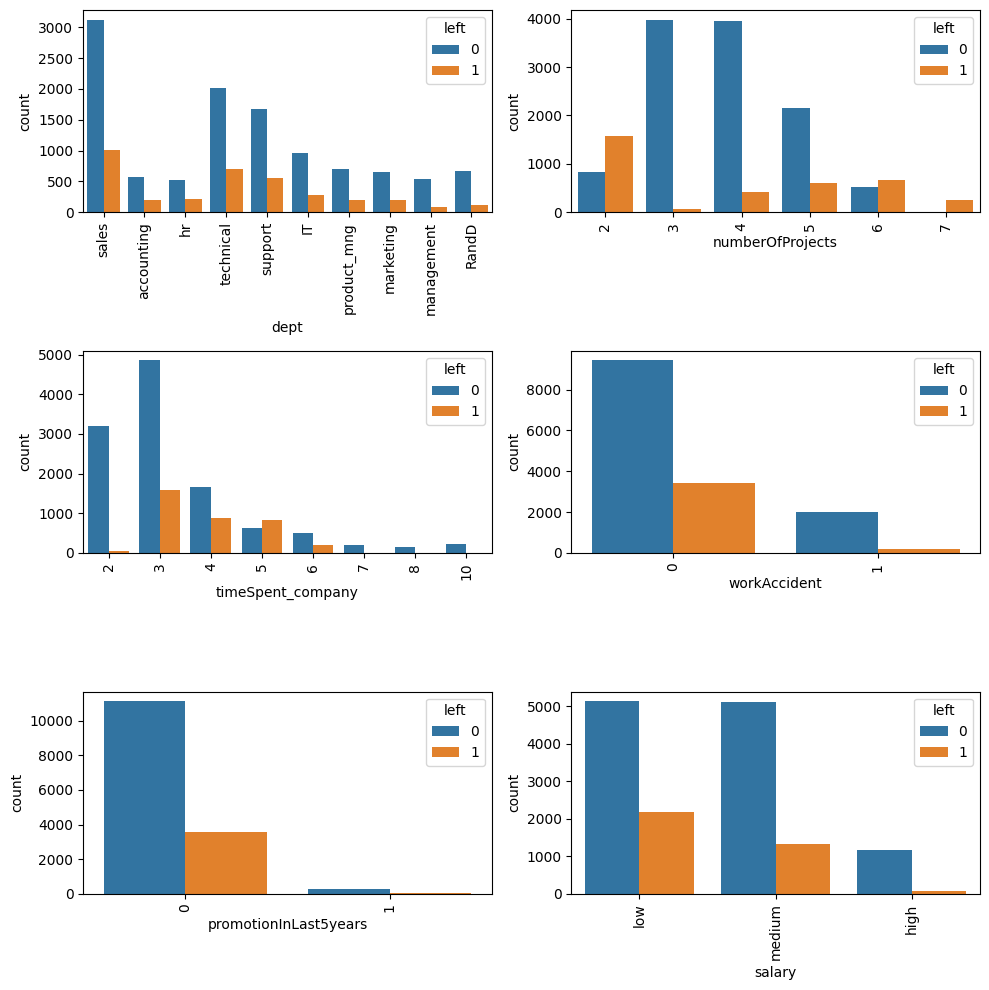

In [42]:
plt.figure(figsize=(10,10))
for p,q in enumerate(feature):
  plt.subplot(3,2,p+1)
  sns.countplot(x =q,hue = 'left',data = df)
  plt.xticks(rotation = 90)
  plt.tight_layout()

conclusion using EDA




Conclusion Using EDA


The HR has to take care of Sales, Technical, and Support departments

The employees having less or more project are churning out. so optimal number of project is 3

The 3 - 5 years is the crucial time for employee who is churning out.

Note: work accident vs left --- it is not giving any information about employee

The employee is leaving if they are not getting promoted in 5 years.

The person having high salary are staying with the company whereas low salary is forcing them to leave or planning to leave.

Using Statstica ANALYSIS

Checking normality using

1.Visulization and skewness

2.shapiro wlk test

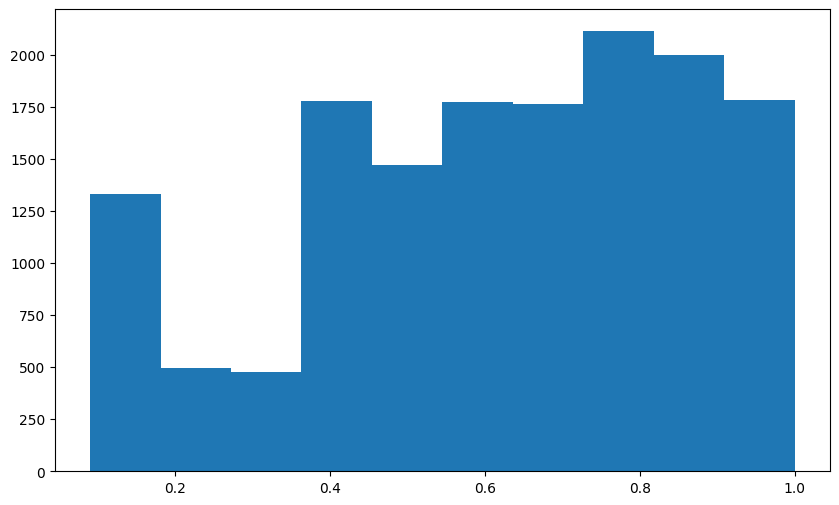

In [44]:
# plotting histogram to visulize
plt.figure(figsize=(10,6))
plt.hist(df["satisfactoryLevel"])
plt.show()

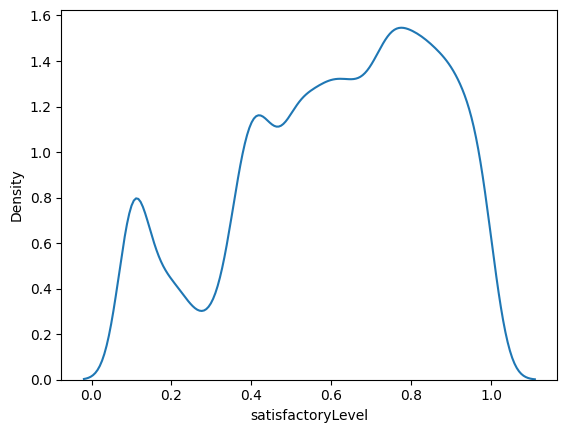

In [45]:
sns.distplot(df["satisfactoryLevel"], hist = False);

In [46]:
df['satisfactoryLevel'].skew()  #Negatively Skewed

np.float64(-0.47638734031617774)

check whether the data is normally distributed or not in satisafactory level column using shapiro-wilk test

In [48]:
from scipy.stats import shapiro

Hypothesis for Shapiro

Null Hypothesis (h0) - data is normally distributed
Alternate Hypothesis (h1) - data is not normally distributed

In [51]:
# Import required library
from scipy.stats import shapiro

# Perform Shapiro-Wilk test
stat, p_value = shapiro(df["satisfactoryLevel"])

# Display results
print("Shapiro-Wilk Test")
print("------------------")
print("Test Statistic:", stat)
print("P-value:", p_value)

# Interpret the result
alpha = 0.05

if p_value > alpha:
    print("\nResult: Data is normally distributed.")
    print("Fail to reject the null hypothesis (H0).")
else:
    print("\nResult: Data is NOT normally distributed.")
    print("Reject the null hypothesis (H0).")

Shapiro-Wilk Test
------------------
Test Statistic: 0.9519112069870423
P-value: 3.2563353219519634e-56

Result: Data is NOT normally distributed.
Reject the null hypothesis (H0).


Conversion of Categorical Data Using Label Encoding

In [52]:
# salary is categorical data
df["salary"].unique()


array(['low', 'medium', 'high'], dtype=object)

In [53]:
# dept is also categorical data
df["dept"].unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'IT',
       'product_mng', 'marketing', 'management', 'RandD'], dtype=object)

In [54]:
df1=df  #copy of our dataset for further analysis

In [55]:
df1[["salary", "dept"]]

,salary,dept
0,low,sales
1,medium,sales
2,medium,sales
3,low,sales
4,low,sales
...,...,...
14989,medium,product_mng
14990,high,technical
14991,medium,IT
14992,low,hr


In [56]:

# Converting the categorical data into num, using Label Encoder
from sklearn.preprocessing import LabelEncoder
l1=LabelEncoder()
df1["salary"]= l1.fit_transform(df1["salary"])
df1["dept"]= l1.fit_transform(df1["dept"])

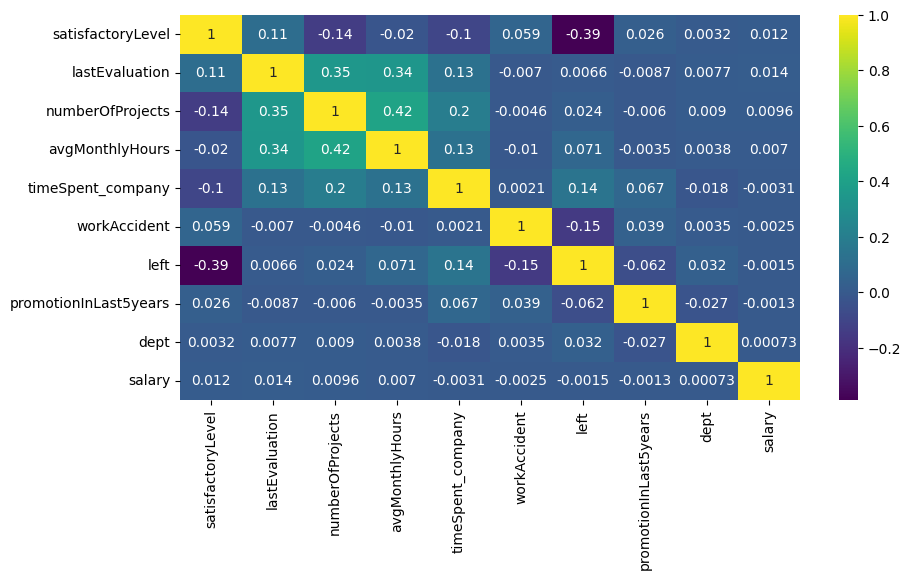

In [57]:
plt.figure(figsize = (10,5))
sns.heatmap(df1.corr(), annot=True, cmap = 'viridis');


Descriptive statistics

In [58]:

df.describe()  #Descriptive Analysis

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent_company,workAccident,left,promotionInLast5years,dept,salary
count,14994.000000,14994.000000,14994.000000,14994.000000,14994.000000,14994.000000,14994.000000,14994.000000,14994.000000,14994.000000
mean,0.612849,0.716064,3.802588,201.039216,3.498199,0.144658,0.238095,0.021275,5.869881,1.347339
std,0.248596,0.171182,1.232350,49.940114,1.460260,0.351767,0.425932,0.144305,2.869016,0.625875
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,4.000000,1.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,7.000000,1.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,8.000000,2.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000,9.000000,2.000000



Random Experiment
Since we are concerned about an employee's leaving the organisation so on the basis of that we will perform a Random Experiment i.e.,

Employee with satisfactoryLevel between 0 and 0.5
Employees who are less satisfied are more prone to leave**
TimeSpent in Company == 2 Years
Employee with less experience often look for change
Average Monthly Hours Spent between 130 and 200
People are gullible to leave if workload is more

In [59]:

# Random experiment
emp = df[(df.satisfactoryLevel>=0)&(df.satisfactoryLevel<=0.50)&(df.timeSpent_company==2)&(df.avgMonthlyHours>=130)&(df.avgMonthlyHours<=200)]


In [60]:
emp.shape

(251, 10)

In [61]:
emp.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent_company,workAccident,left,promotionInLast5years,dept,salary
35,0.13,0.78,6,152,2,0,1,0,8,1
379,0.48,0.78,2,198,2,0,1,0,9,2
413,0.34,0.67,4,141,2,0,1,0,7,1
1239,0.14,0.47,4,175,2,0,1,0,1,2
1426,0.19,0.58,5,182,2,0,0,0,9,2


<Axes: ylabel='Density'>

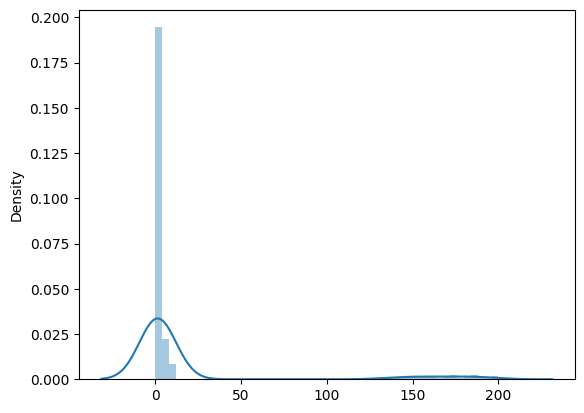

In [63]:
sns.distplot(emp)

In [64]:

emp["left"].value_counts() #Only 6 People are leaving

,count
left,
0,237
1,14


In [65]:
emp["avgMonthlyHours"].mean()  #We will Test this statistic

np.float64(166.9561752988048)

By Looking at the above data we found out 167.225 is the average monthly hours for employee with 2 Years of Experience. We will check if it is same for people with more years of experience with the help of hypothesis testing.

We assume if People with less experience are getting to work more than people with higher work experience

Hypothesis Testing
1. T-test
Used for checking difference in means between samples/popluation

a. One sample T-test for Mean
It tells us whether the mean of sample and population are different or not

Problem Statement
The average monthly hours of a employee having 2 years experience is 167. Is it same for employees having more than 2 years experience?

Condition - Satisfactory level of a employee is from 0-0.5 and AvgMonthlyhours is from 130-200

In [67]:

employee = df[(df.satisfactoryLevel>=0)&(df.satisfactoryLevel<=0.50)&(df.timeSpent_company>=3)&(df.avgMonthlyHours>=130)&(df.avgMonthlyHours<=200)]

In [68]:
employee.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent_company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,7,1
3,0.37,0.52,2,159,3,0,1,0,7,1
4,0.41,0.50,2,153,3,0,1,0,7,1
7,0.42,0.53,2,142,3,0,1,0,7,1
8,0.45,0.54,2,135,3,0,1,0,7,1


In [69]:
employee.shape

(2220, 10)

State Hypothesis

In [71]:

#Null hypothesis: avg monthly hours of a employee having 2 yrs exp and the employee more than that is same i.e, 167 hrs

In [70]:

#Alternate hypothesis: avg monthly hours of a employee having 2 yrs exp doesnot have same avg monthly hours with more than 2 yrs exp employee

Sampling

In [74]:
sample_size = 100
sample1 = employee.sample(sample_size,random_state=0)

In [75]:

# population mean
population_mean=167

In [76]:

# sample mean
print(sample1["avgMonthlyHours"].mean())

154.72


In [78]:

from scipy.stats import ttest_1samp

statistics,pvalue=ttest_1samp(sample1["avgMonthlyHours"],population_mean)
print(statistics,pvalue)

-6.886920853520406 5.30340856619246e-10


In [80]:
#Critical Value Approach

# Degrees of freedom for Sample
dof=100-1
print(dof)

99


In [81]:
#confidence level=.95
alpha= 0.05
CL = 1-alpha

We Can Check Critical Value Using T Student Distribution Table or Else:

In [82]:
from scipy.stats import t

In [83]:

#Critical Value

cv= t.ppf([alpha/2, 1-alpha/2], dof)  #ppf = percent point function #Two Tailed Test
print(cv)

[-1.98421695  1.98421695]



# p value is less than 0.05
#reject null hypothesis,

#avg monthly hours is not 167 hours for employees having more than 2 yrs of exp

z-test for proportions

In [ ]:

# Null hypothesis - percentage of employee leaving the company having the exp of 2 years is same as employee having exp more than 2 yrs
# Alternate hypothesis - percentage of employee leaving the company having the exp of 2 years is different from the employee having exp more than 2 yrs

In [84]:

from statsmodels.stats.proportion import proportions_ztest

In [85]:
employee.shape

(2220, 10)

In [86]:
sample_size

100

In [87]:
sample1=employee.sample(sample_size,random_state=0)


In [88]:

count=sample1["left"].value_counts()
count


,count
left,
1,65
0,35


In [89]:

nobs=len(sample1["left"])

In [90]:
p0 = 0.3


In [91]:
sample1["left"].value_counts()/nobs

,count
left,
1,0.65
0,0.35


In [92]:

statistic_oneprop,pvalue_oneprop=proportions_ztest(count=count,nobs=nobs,value=p0,alternative="two-sided",prop_var=False)

p-value  approach

In [93]:

print(statistic_oneprop,pvalue_oneprop)

7.850462293418876e-16 0.9999999999999993


Critical Value Approach

In [94]:
from scipy.stats import norm
cv_norm=norm.ppf([alpha/2,1-alpha/2])
print(cv_norm)

[-1.95996398  1.95996398]


One Proportion Z-test Conclusion

In [95]:

# p value is greater than 0.05 accept null hypothesis and reject alternate hypothesis
# percentage of employee leaving the company having the exp of 2 years is same as employee having exp more than 2 yrs


Two sample T-test for Mean

In [96]:

df1.head(3)

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent_company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,7,1
1,0.80,0.86,5,262,6,0,1,0,7,2
2,0.11,0.88,7,272,4,0,1,0,7,2



Problem Statement

Is the mean avg monthly hours of a employee having experience of 2-5 yrs is the same as that for employee having exp 6 - 10 yrs ?

In [97]:
# Null hypothesis - Means are same
# Alternate hypothesis - Means are not same

In [98]:
e1=df1[(df1.timeSpent_company>=2) & (df1.timeSpent_company<=5)]
e2=df1[(df1.timeSpent_company>=6) & (df1.timeSpent_company<=10)]

In [99]:
e1.shape

(13712, 10)

In [100]:
e2.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent_company,workAccident,left,promotionInLast5years,dept,salary
1,0.80,0.86,5,262,6,0,1,0,7,2
13,0.78,0.99,4,255,6,0,1,0,7,1
26,0.84,0.87,4,246,6,0,1,0,3,1
33,0.57,0.70,3,273,6,0,1,0,8,1
63,0.90,1.00,5,221,6,0,1,0,7,2


In [101]:
e2.shape

(1282, 10)

In [102]:

s1=e1.sample(200,random_state=0)
s2=e2.sample(200,random_state=0)

In [103]:
 from scipy.stats import ttest_ind

In [104]:
ttest_ind(s1["avgMonthlyHours"],s2["avgMonthlyHours"])

TtestResult(statistic=np.float64(-0.15128007814596742), pvalue=np.float64(0.8798314311128589), df=np.float64(398.0))


 p value > 0.05 Hence accept null hypothesis

 The mean avg monthly hours of a employee having experience of 2-5 yrs is the same as that for employee having exp 6 - 10 yrs

F-test for variance


In [ ]:
# compute the f-statstics of the previous problem statement


In [ ]:

# Null hypothesis - Variances are same
# Alternate hypothesis - Variances are not same
#(# F-test for variance is used to test if the variances of two populations are equal)

In [106]:
# Sample Variance
print(s1.avgMonthlyHours.var())
print(s2.avgMonthlyHours.var())


2530.3693467336707
2517.3325628140697


In [109]:
# Degrees offreedom for sample
df1=len(s1)-1
df2=len(s2)-1

P-value Approach

In [112]:

# Computing f statistic
from scipy.stats import f
F=s1.avgMonthlyHours.var()/s2.avgMonthlyHours.var()
print(F)


# value is greater than 0.05 ,Hence Accept NUll hypothesis

1.00517880875661


In [113]:
import scipy.stats

Critical Value Approach

In [114]:
cv = scipy.stats.f.cdf(F, df1, df2) #Critical Value

In [115]:

f.ppf([alpha/2,1-alpha/2],df1, df2)

array([0.75678659, 1.32137648])

Two variance F-test conclusion

# p value is >0.05, accept null hypothesis, equal variances


Conclusions Based on Statistical Analysis


One-Sample t-Test — Average Monthly Working Hours:
The one-sample t-test indicates that the average monthly working hours for employees with 2 years of experience are statistically different from the benchmark of 167 hours per month. This suggests that employees at this experience level may be experiencing higher or lower-than-expected workload. Combined with the EDA findings, where employees with less than 2 years of experience show relatively high monthly working hours, workload and work pressure could be potential contributors to employee attrition.


One-Sample Proportion Test — Attrition by Experience:
The one-sample proportion analysis suggests that the attrition proportion among employees with around 2 years of experience is not significantly different from that of employees with more than 2 years of experience. This indicates that experience alone may not be a strong differentiating factor for attrition. Therefore, organizations should investigate other factors such as number of projects handled, workload, career progression, promotion opportunities, job satisfaction, and compensation to understand the underlying drivers of employee turnover.


Two-Sample t-Test — Working Hours Across Experience Groups:
The two-sample t-test suggests that there is no statistically significant difference in average monthly working hours between employees with 2–5 years and 6–10 years of experience. This indicates that workload, measured through monthly working hours, remains relatively consistent across these experience groups. However, EDA reveals that employees with less than 2 years of experience tend to work comparatively longer hours, which may indicate a higher workload or adjustment pressure during the early stages of their careers. This makes early-career workload management an important area for organizations seeking to reduce attrition.